In [1]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('✅ Import xong!')

✅ Import xong!


In [2]:
df1 = pd.read_csv('/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv')
df2 = pd.read_csv('/kaggle/input/datasets/titeohihi/homemade-features-3-sec/features_3_sec.csv')

for name, df in [('Dataset gốc', df1), ('Dataset tự tạo', df2)]:
    print(f'{name}: {df.shape[0]} dòng × {df.shape[1]} cột')
    print(f'  Phân phối: {dict(df["label"].value_counts().sort_index())}\n')

Dataset gốc: 9990 dòng × 60 cột
  Phân phối: {'blues': np.int64(1000), 'classical': np.int64(998), 'country': np.int64(997), 'disco': np.int64(999), 'hiphop': np.int64(998), 'jazz': np.int64(1000), 'metal': np.int64(1000), 'pop': np.int64(1000), 'reggae': np.int64(1000), 'rock': np.int64(998)}

Dataset tự tạo: 9981 dòng × 60 cột
  Phân phối: {'blues': np.int64(1000), 'classical': np.int64(998), 'country': np.int64(997), 'disco': np.int64(999), 'hiphop': np.int64(998), 'jazz': np.int64(990), 'metal': np.int64(1000), 'pop': np.int64(1000), 'reggae': np.int64(1000), 'rock': np.int64(999)}



In [3]:
print("PREPROCESSING")

def preprocess(df, test_size=0.15, val_size=0.15, random_state=RANDOM_SEED):
    """
    Split 3 chiều Train(~70%) / Val(~15%) / Test(~15%) theo group 'original_file'.
    - GroupShuffleSplit: các đoạn 3 giây của cùng một bài nhạc chỉ nằm trong một tập.
    - Scaler fit CHỈ trên train, transform val và test.
    - Nếu df không có cột 'original_file', fallback về StratifiedShuffleSplit và in cảnh báo.
    """
    meta_cols  = ['filename', 'length']   # drop khỏi features, KHÔNG drop original_file sớm
    group_col  = 'original_file'
    feature_df = df.drop(columns=[c for c in meta_cols if c in df.columns])

    le = LabelEncoder()
    y  = le.fit_transform(feature_df['label'])
    X  = feature_df.drop(columns=['label', group_col], errors='ignore').values.astype(np.float32)
    feature_names = feature_df.drop(columns=['label', group_col], errors='ignore').columns.tolist()

    has_group = group_col in df.columns
    if not has_group:
        print('  ⚠️  Không tìm thấy cột "original_file" — fallback về StratifiedShuffleSplit.')

    # ── Bước 1: Tách test ────────────────────────────────────────────────────
    if has_group:
        groups   = df[group_col].values
        gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        trainval_idx, test_idx = next(gss_test.split(X, y, groups=groups))
    else:
        from sklearn.model_selection import StratifiedShuffleSplit
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        trainval_idx, test_idx = next(sss.split(X, y))

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval, y_test = y[trainval_idx], y[test_idx]

    # ── Bước 2: Tách val từ phần train+val ───────────────────────────────────
    val_ratio = val_size / (1 - test_size)   # ~0.1765 để đạt 15% tổng

    if has_group:
        groups_trainval = groups[trainval_idx]
        gss_val = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=random_state)
        train_idx2, val_idx2 = next(gss_val.split(X_trainval, y_trainval, groups=groups_trainval))
    else:
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=random_state)
        train_idx2, val_idx2 = next(sss2.split(X_trainval, y_trainval))

    X_train, X_val = X_trainval[train_idx2], X_trainval[val_idx2]
    y_train, y_val = y_trainval[train_idx2], y_trainval[val_idx2]

    # ── Scale — fit chỉ trên train ───────────────────────────────────────────
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)

    total = len(y)
    split_method = 'GroupShuffleSplit (theo bài nhạc)' if has_group else 'StratifiedShuffleSplit'
    print(f'  Phương pháp split : {split_method}')
    print(f'  Train : {len(y_train):5d} ({len(y_train)/total*100:.1f}%)')
    print(f'  Val   : {len(y_val):5d} ({len(y_val)/total*100:.1f}%)')
    print(f'  Test  : {len(y_test):5d} ({len(y_test)/total*100:.1f}%)')

    # ── Kiểm tra không có overlap giữa các tập ───────────────────────────────
    if has_group:
        train_songs = set(groups[trainval_idx][train_idx2])
        val_songs   = set(groups[trainval_idx][val_idx2])
        test_songs  = set(groups[test_idx])
        overlap_tv  = train_songs & val_songs
        overlap_tt  = train_songs & test_songs
        overlap_vt  = val_songs   & test_songs
        if overlap_tv or overlap_tt or overlap_vt:
            print(f'  ❌ Vẫn còn overlap! TV={len(overlap_tv)}, TT={len(overlap_tt)}, VT={len(overlap_vt)}')
        else:
            print(f'  ✅ Không có overlap bài nhạc ({len(set(groups))} bài độc lập hoàn toàn)')

    return {
        'X_train': X_train_sc, 'X_val': X_val_sc, 'X_test': X_test_sc,
        'y_train': y_train,    'y_val': y_val,     'y_test': y_test,
        'le': le, 'scaler': scaler,
        'feature_names': feature_names
    }

print('\n--- Dataset gốc ---')
d1 = preprocess(df1)
print('\n--- Dataset tự tạo ---')
d2 = preprocess(df2)

PREPROCESSING

--- Dataset gốc ---
  ⚠️  Không tìm thấy cột "original_file" — fallback về StratifiedShuffleSplit.
  Phương pháp split : StratifiedShuffleSplit
  Train :  6992 (70.0%)
  Val   :  1499 (15.0%)
  Test  :  1499 (15.0%)

--- Dataset tự tạo ---
  ⚠️  Không tìm thấy cột "original_file" — fallback về StratifiedShuffleSplit.
  Phương pháp split : StratifiedShuffleSplit
  Train :  6986 (70.0%)
  Val   :  1497 (15.0%)
  Test  :  1498 (15.0%)


In [4]:
baseline_models = {
    'KNN'          : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20,
                                             n_jobs=-1, random_state=RANDOM_SEED),
    'SVM'          : SVC(kernel='rbf', C=10, gamma='scale',
                         probability=True, random_state=RANDOM_SEED),
    'XGBoost'      : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                    n_jobs=-1, eval_metric='mlogloss',
                                    random_state=RANDOM_SEED, verbosity=0),
}

def run_baseline(data, label):
    print(f'\n{'='*50}')
    print(f'  BASELINE — {label}')
    print(f'{'='*50}')
    results = {}
    for name, model in baseline_models.items():
        m = copy.deepcopy(model)
        m.fit(data['X_train'], data['y_train'])
        val_acc = accuracy_score(data['y_val'], m.predict(data['X_val']))
        val_f1  = f1_score(data['y_val'], m.predict(data['X_val']), average='macro')
        results[name] = {'model': m, 'val_acc': val_acc, 'val_f1': val_f1}
        print(f'  {name:<15} Val Acc: {val_acc:.4f}  |  Val F1: {val_f1:.4f}')
    best = max(results, key=lambda k: results[k]['val_acc'])
    print(f'  → Best (Val): {best} ({results[best]["val_acc"]:.4f})')
    return results

baseline1 = run_baseline(d1, 'Dataset gốc')
baseline2 = run_baseline(d2, 'Dataset tự tạo')


  BASELINE — Dataset gốc
  KNN             Val Acc: 0.8706  |  Val F1: 0.8706
  Random Forest   Val Acc: 0.8499  |  Val F1: 0.8495
  SVM             Val Acc: 0.9119  |  Val F1: 0.9114
  XGBoost         Val Acc: 0.8906  |  Val F1: 0.8909
  → Best (Val): SVM (0.9119)

  BASELINE — Dataset tự tạo
  KNN             Val Acc: 0.8871  |  Val F1: 0.8865
  Random Forest   Val Acc: 0.8717  |  Val F1: 0.8710
  SVM             Val Acc: 0.9105  |  Val F1: 0.9103
  XGBoost         Val Acc: 0.8958  |  Val F1: 0.8957
  → Best (Val): SVM (0.9105)


In [5]:
# ── Định nghĩa search space ──────────────────────────────
# Dùng CV=3 trên train set để tìm params, sau đó đánh giá trên val

param_grids = {
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=-1),
        'params': {
            'n_neighbors': [3, 5, 7, 11, 15],
            'weights'    : ['uniform', 'distance'],
            'metric'     : ['euclidean', 'manhattan']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_jobs=-1, random_state=RANDOM_SEED),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth'   : [None, 20, 30],
            'max_features': ['sqrt', 'log2'],
            'min_samples_split': [2, 5]
        }
    },
    'SVM': {
        'model': SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
        'params': {
            'C'    : [1, 5, 10, 50, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(n_jobs=-1, eval_metric='mlogloss',
                                random_state=RANDOM_SEED, verbosity=0),
        'params': {
            'n_estimators' : [100, 200, 300],
            'max_depth'    : [4, 6, 8],
            'learning_rate': [0.05, 0.1, 0.2],
            'subsample'    : [0.8, 1.0]
        }
    }
}

def run_grid_search(data, label):
    print(f'\n{'='*55}')
    print(f'  GRID SEARCH — {label}')
    print(f'{'='*55}')
    tuned_results = {}

    for name, cfg in param_grids.items():
        print(f'\n  🔍 Tuning {name}...')

        gs = GridSearchCV(
            cfg['model'], cfg['params'],
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
            scoring='accuracy', n_jobs=-1, verbose=0
        )
        gs.fit(data['X_train'], data['y_train'])

        # Đánh giá best model trên Val set
        best_model = gs.best_estimator_
        val_pred   = best_model.predict(data['X_val'])
        val_acc    = accuracy_score(data['y_val'], val_pred)
        val_f1     = f1_score(data['y_val'], val_pred, average='macro')

        tuned_results[name] = {
            'model'     : best_model,
            'best_params': gs.best_params_,
            'cv_acc'    : gs.best_score_,
            'val_acc'   : val_acc,
            'val_f1'    : val_f1
        }

        print(f'     Best params : {gs.best_params_}')
        print(f'     CV Acc      : {gs.best_score_:.4f}')
        print(f'     Val Acc     : {val_acc:.4f}  |  Val F1: {val_f1:.4f}')

    best_name = max(tuned_results, key=lambda k: tuned_results[k]['val_acc'])
    print(f'\n  🏆 Best sau tuning (Val): {best_name} ({tuned_results[best_name]["val_acc"]:.4f})')
    return tuned_results

print('⏳ Đang chạy Grid Search (mất 5-15 phút)...')
tuned1 = run_grid_search(d1, 'Dataset gốc')
tuned2 = run_grid_search(d2, 'Dataset tự tạo')

⏳ Đang chạy Grid Search (mất 5-15 phút)...

  GRID SEARCH — Dataset gốc

  🔍 Tuning KNN...
     Best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
     CV Acc      : 0.8924
     Val Acc     : 0.9226  |  Val F1: 0.9227

  🔍 Tuning Random Forest...
     Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
     CV Acc      : 0.8424
     Val Acc     : 0.8599  |  Val F1: 0.8596

  🔍 Tuning SVM...
     Best params : {'C': 10, 'gamma': 'scale'}
     CV Acc      : 0.8894
     Val Acc     : 0.9119  |  Val F1: 0.9114

  🔍 Tuning XGBoost...
     Best params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
     CV Acc      : 0.8747
     Val Acc     : 0.9046  |  Val F1: 0.9048

  🏆 Best sau tuning (Val): KNN (0.9226)

  GRID SEARCH — Dataset tự tạo

  🔍 Tuning KNN...
     Best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
     CV Acc      : 0.8931
     Val Acc    

In [6]:
def compare_baseline_tuned(baseline, tuned, dataset_label):
    print(f'\n{'='*65}')
    print(f'  SO SÁNH BASELINE vs TUNED — {dataset_label} (Val set)')
    print(f'{'='*65}')
    print(f'  {'Model':<18} {'Baseline':>10} {'Tuned':>10} {'Δ':>8}')
    print(f'  {'-'*50}')
    for name in baseline:
        b = baseline[name]['val_acc']
        t = tuned[name]['val_acc']
        delta = t - b
        arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
        print(f'  {name:<18} {b:>10.4f} {t:>10.4f} {arrow}{abs(delta):>6.4f}')

compare_baseline_tuned(baseline1, tuned1, 'Dataset gốc')
compare_baseline_tuned(baseline2, tuned2, 'Dataset tự tạo')


  SO SÁNH BASELINE vs TUNED — Dataset gốc (Val set)
  Model                Baseline      Tuned        Δ
  --------------------------------------------------
  KNN                    0.8706     0.9226 ↑0.0520
  Random Forest          0.8499     0.8599 ↑0.0100
  SVM                    0.9119     0.9119 =0.0000
  XGBoost                0.8906     0.9046 ↑0.0140

  SO SÁNH BASELINE vs TUNED — Dataset tự tạo (Val set)
  Model                Baseline      Tuned        Δ
  --------------------------------------------------
  KNN                    0.8871     0.9312 ↑0.0441
  Random Forest          0.8717     0.8684 ↓0.0033
  SVM                    0.9105     0.9105 =0.0000
  XGBoost                0.8958     0.9078 ↑0.0120


In [7]:
def final_evaluation(tuned, data, dataset_label):
    print(f'\n{'='*60}')
    print(f'  FINAL TEST SET EVALUATION — {dataset_label}')
    print(f'{'='*60}')

    final_results = {}
    for name, res in tuned.items():
        model     = res['model']
        test_pred = model.predict(data['X_test'])
        test_acc  = accuracy_score(data['y_test'], test_pred)
        test_f1_m = f1_score(data['y_test'], test_pred, average='macro')
        test_f1_w = f1_score(data['y_test'], test_pred, average='weighted')
        final_results[name] = {
            'test_acc' : test_acc,
            'test_f1_m': test_f1_m,
            'test_f1_w': test_f1_w,
            'test_pred': test_pred
        }
        print(f'  {name:<15}  Acc: {test_acc:.4f}  F1_macro: {test_f1_m:.4f}  F1_weighted: {test_f1_w:.4f}')

    best_name = max(final_results, key=lambda k: final_results[k]['test_acc'])
    best      = final_results[best_name]
    print(f'\n  🏆 Best model: {best_name} (Test Acc = {best["test_acc"]:.4f})')
    print(f'\n  Classification Report ({best_name}):')
    print(classification_report(
        data['y_test'], best['test_pred'],
        target_names=data['le'].classes_
    ))
    return final_results, best_name

final1, best1 = final_evaluation(tuned1, d1, 'Dataset gốc')
final2, best2 = final_evaluation(tuned2, d2, 'Dataset tự tạo')


  FINAL TEST SET EVALUATION — Dataset gốc
  KNN              Acc: 0.9139  F1_macro: 0.9136  F1_weighted: 0.9136
  Random Forest    Acc: 0.8632  F1_macro: 0.8626  F1_weighted: 0.8626
  SVM              Acc: 0.9066  F1_macro: 0.9061  F1_weighted: 0.9061
  XGBoost          Acc: 0.8986  F1_macro: 0.8984  F1_weighted: 0.8984

  🏆 Best model: KNN (Test Acc = 0.9139)

  Classification Report (KNN):
              precision    recall  f1-score   support

       blues       0.93      0.92      0.93       150
   classical       0.90      0.97      0.93       150
     country       0.86      0.84      0.85       149
       disco       0.85      0.95      0.90       150
      hiphop       0.96      0.91      0.94       150
        jazz       0.91      0.91      0.91       150
       metal       0.94      0.99      0.96       150
         pop       0.95      0.85      0.90       150
      reggae       0.92      0.96      0.94       150
        rock       0.92      0.85      0.89       150

    accu

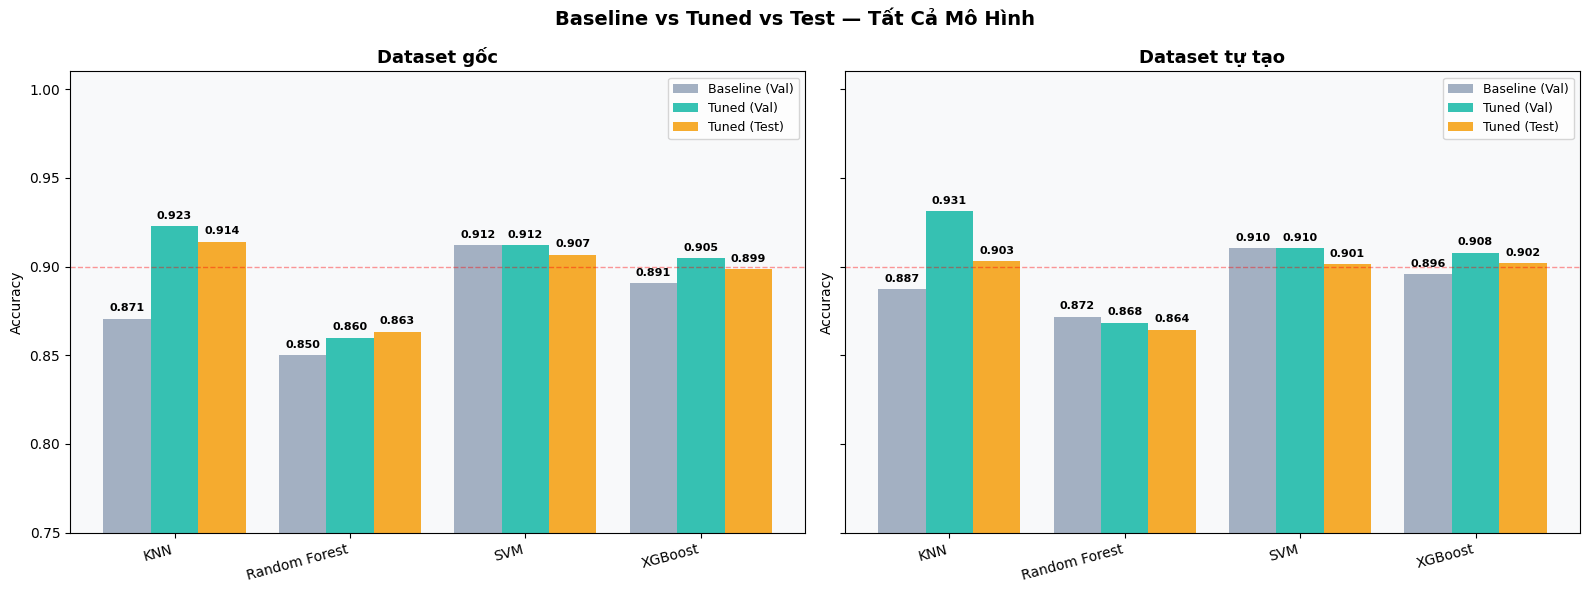

In [8]:
model_names = list(tuned1.keys())

# ── Bar chart so sánh 4 nhóm ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, baseline, tuned, final, label in [
    (axes[0], baseline1, tuned1, final1, 'Dataset gốc'),
    (axes[1], baseline2, tuned2, final2, 'Dataset tự tạo')
]:
    x     = np.arange(len(model_names))
    w     = 0.27
    base_accs  = [baseline[n]['val_acc']  for n in model_names]
    tuned_accs = [tuned[n]['val_acc']     for n in model_names]
    test_accs  = [final[n]['test_acc']    for n in model_names]

    b1 = ax.bar(x - w,   base_accs,  w, label='Baseline (Val)', color='#94A3B8', alpha=0.85)
    b2 = ax.bar(x,       tuned_accs, w, label='Tuned (Val)',     color='#14B8A6', alpha=0.85)
    b3 = ax.bar(x + w,   test_accs,  w, label='Tuned (Test)',    color='#F59E0B', alpha=0.85)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_ylim(0.75, 1.01)
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy'); ax.legend(fontsize=9)
    ax.set_facecolor('#f8f9fa')
    ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, linewidth=1, label='90% target')

plt.suptitle('Baseline vs Tuned vs Test — Tất Cả Mô Hình', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

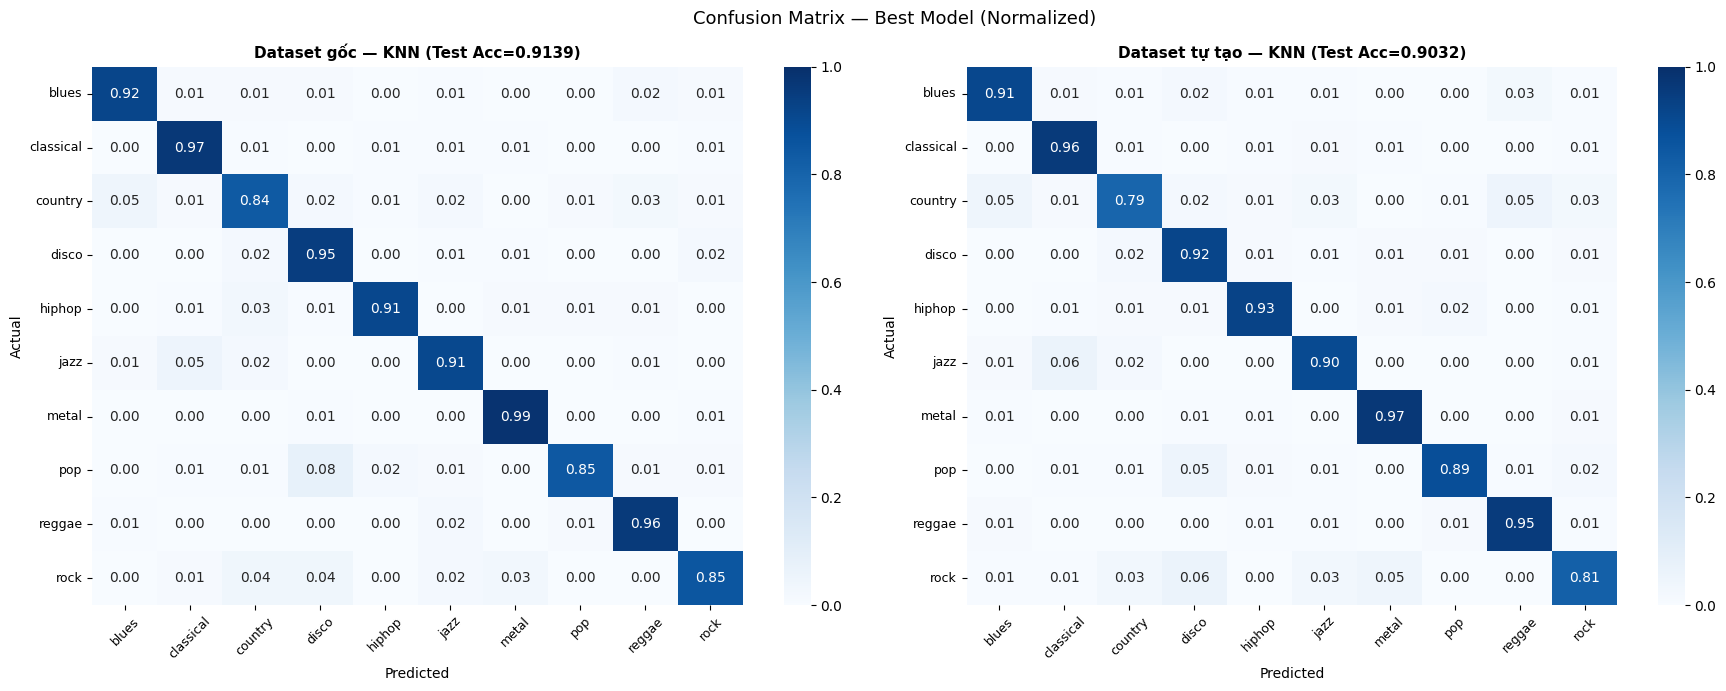

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, final, data, best_name, label in [
    (axes[0], final1, d1, best1, 'Dataset gốc'),
    (axes[1], final2, d2, best2, 'Dataset tự tạo')
]:
    cm      = confusion_matrix(data['y_test'], final[best_name]['test_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=data['le'].classes_,
                yticklabels=data['le'].classes_,
                ax=ax, vmin=0, vmax=1)
    acc = final[best_name]['test_acc']
    ax.set_title(f'{label} — {best_name} (Test Acc={acc:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Confusion Matrix — Best Model (Normalized)', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
rows = []
for name in model_names:
    rows.append({
        'Model'         : name,
        'DS1 Baseline'  : f"{baseline1[name]['val_acc']:.4f}",
        'DS1 Tuned Val' : f"{tuned1[name]['val_acc']:.4f}",
        'DS1 Test'      : f"{final1[name]['test_acc']:.4f}",
        'DS2 Baseline'  : f"{baseline2[name]['val_acc']:.4f}",
        'DS2 Tuned Val' : f"{tuned2[name]['val_acc']:.4f}",
        'DS2 Test'      : f"{final2[name]['test_acc']:.4f}",
    })

df_summary = pd.DataFrame(rows)
df_summary.to_csv('/kaggle/working/final_summary.csv', index=False)

print('\n📊 BẢNG TỔNG KẾT CUỐI CÙNG')
print('='*85)
print(df_summary.to_string(index=False))
print('='*85)

# Highlight best
best_overall_ds1 = max(final1, key=lambda k: final1[k]['test_acc'])
best_overall_ds2 = max(final2, key=lambda k: final2[k]['test_acc'])
print(f'\n🏆 Dataset gốc    — Best: {best_overall_ds1} (Test={final1[best_overall_ds1]["test_acc"]:.4f})')
print(f'🏆 Dataset tự tạo — Best: {best_overall_ds2} (Test={final2[best_overall_ds2]["test_acc"]:.4f})')
print(f'\n✅ Đã lưu: final_summary.csv, comparison_all.png, confusion_matrices.png')


📊 BẢNG TỔNG KẾT CUỐI CÙNG
        Model DS1 Baseline DS1 Tuned Val DS1 Test DS2 Baseline DS2 Tuned Val DS2 Test
          KNN       0.8706        0.9226   0.9139       0.8871        0.9312   0.9032
Random Forest       0.8499        0.8599   0.8632       0.8717        0.8684   0.8645
          SVM       0.9119        0.9119   0.9066       0.9105        0.9105   0.9012
      XGBoost       0.8906        0.9046   0.8986       0.8958        0.9078   0.9019

🏆 Dataset gốc    — Best: KNN (Test=0.9139)
🏆 Dataset tự tạo — Best: KNN (Test=0.9032)

✅ Đã lưu: final_summary.csv, comparison_all.png, confusion_matrices.png
